In [1]:
!pip install timm -q

In [2]:
# import os

# print("Scanning Kaggle Input Directory \n")

# start_path = '/kaggle/input'

# for root, dirs, files in os.walk(start_path):
#     if len(dirs) > 0:
#         print(f"Found Directory: {root}")
#         print(f"Contains {len(dirs)} subfolders (First 5: {dirs[:5]})")
        
#         # If we see familiar names, flag them
#         if 'Tomato' in str(dirs) or 'Apple' in str(dirs) or 'Corn' in str(dirs):
#             print("Likely data location")
            
#     if root.count(os.sep) - start_path.count(os.sep) > 3:
#         continue

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pv_path = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
pd_path = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train'

def get_classes(dir_path):
    if not os.path.exists(dir_path):
        return []
    return sorted([d for d in os.listdir(dir_path) if os.path.isdir(os.path.join(dir_path, d))])

pv_classes = get_classes(pv_path)
pd_classes = get_classes(pd_path)

def normalize(name):
    # Lowercase everything
    name = name.lower()

    name = name.replace('_', ' ').replace('-', ' ')
    
    name = name.replace(' leaf ', ' ')
    
    return " ".join(name.split())

mapping = {}
print(f"{'PlantVillage (Train)':<30} | {'PlantDoc (Val)':<30} | {'Status'}")
print("-" * 75)

common_classes = []

for pv in pv_classes:
    norm_pv = normalize(pv)
    match = None
    for pd_c in pd_classes:
        if norm_pv == normalize(pd_c):
            match = pd_c
            break
    
    status = "MATCH" if match else "No Match"
    print(f"{pv:<30} | {str(match):<30} | {status}")
    
    if match:
        mapping[pv] = match
        common_classes.append(pv)

print(f"\nFound {len(mapping)} common classes out of {len(pv_classes)} total training classes.")

PlantVillage (Train)           | PlantDoc (Val)                 | Status
---------------------------------------------------------------------------
Pepper__bell___Bacterial_spot  | None                           | No Match
Pepper__bell___healthy         | None                           | No Match
Potato___Early_blight          | Potato leaf early blight       | MATCH
Potato___Late_blight           | Potato leaf late blight        | MATCH
Potato___healthy               | None                           | No Match
Tomato_Bacterial_spot          | Tomato leaf bacterial spot     | MATCH
Tomato_Early_blight            | None                           | No Match
Tomato_Late_blight             | Tomato leaf late blight        | MATCH
Tomato_Leaf_Mold               | None                           | No Match
Tomato_Septoria_leaf_spot      | Tomato Septoria leaf spot      | MATCH
Tomato_Spider_mites_Two_spotted_spider_mite | None                           | No Match
Tomato__Target_Spot         

In [4]:
import os
import pandas as pd

pv_path = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
pd_path = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train'

def get_classes(path):
    if not os.path.exists(path): return []
    return sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])

pv_classes = get_classes(pv_path)
pd_classes = get_classes(pd_path)

max_len = max(len(pv_classes), len(pd_classes))
pv_classes += [''] * (max_len - len(pv_classes))
pd_classes += [''] * (max_len - len(pd_classes))

# Display side-by-side
df = pd.DataFrame({
    'PlantVillage (Train)': pv_classes, 
    'PlantDoc (Val/Real World)': pd_classes
})

# Adjust pandas settings to show everything
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
print(df)

                           PlantVillage (Train)   PlantDoc (Val/Real World)
0                 Pepper__bell___Bacterial_spot             Apple Scab Leaf
1                        Pepper__bell___healthy                  Apple leaf
2                         Potato___Early_blight             Apple rust leaf
3                          Potato___Late_blight            Bell_pepper leaf
4                              Potato___healthy       Bell_pepper leaf spot
5                         Tomato_Bacterial_spot              Blueberry leaf
6                           Tomato_Early_blight                 Cherry leaf
7                            Tomato_Late_blight         Corn Gray leaf spot
8                              Tomato_Leaf_Mold            Corn leaf blight
9                     Tomato_Septoria_leaf_spot              Corn rust leaf
10  Tomato_Spider_mites_Two_spotted_spider_mite                  Peach leaf
11                          Tomato__Target_Spot    Potato leaf early blight
12        To

In [5]:
CLASS_MAPPING = {
    # PEPPER
    'Pepper__bell___Bacterial_spot': 'Bell_pepper leaf spot',
    'Pepper__bell___healthy': 'Bell_pepper leaf',

    # POTATO (Note: "Potato Healthy" dropped as PlantDoc lacks a match)
    'Potato___Early_blight': 'Potato leaf early blight',
    'Potato___Late_blight': 'Potato leaf late blight',

    # TOMATO
    'Tomato_Bacterial_spot': 'Tomato leaf bacterial spot',
    'Tomato_Early_blight': 'Tomato Early blight leaf',
    'Tomato_Late_blight': 'Tomato leaf late blight',
    'Tomato_Leaf_Mold': 'Tomato mold leaf',
    'Tomato_Septoria_leaf_spot': 'Tomato Septoria leaf spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus': 'Tomato leaf yellow virus',
    'Tomato__Tomato_mosaic_virus': 'Tomato leaf mosaic virus',
    'Tomato_healthy': 'Tomato leaf', 
}

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Copying here for faster use
pv_path = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
pd_path = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train'

class HybridPlantDataset(Dataset):
    def __init__(self, root_dir, source_type, mapping, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(list(mapping.keys())) # Ensure consistent order
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        print(f"Initializing {source_type.upper()} Dataset...")
        
        valid_images = 0
        
        for pv_name, pd_name in mapping.items():
            # Determine which folder name to look for based on source
            target_folder = pv_name if source_type == 'plantvillage' else pd_name
            class_path = os.path.join(root_dir, target_folder)
            
            # Map back to the Unified Class ID (always based on pv keys)
            label_idx = self.class_to_idx[pv_name]
            
            if os.path.exists(class_path):
                files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                for img_file in files:
                    self.image_paths.append(os.path.join(class_path, img_file))
                    self.labels.append(label_idx)
                valid_images += len(files)
                # print(f"   Loaded {len(files)} images for class: {target_folder}") # Uncomment for verbose
            else:
                print(f"WARNING: Folder not found: {target_folder}")

        print(f"Loaded {valid_images} total images across {len(mapping)} classes.\n")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a dummy tensor or handle gracefully
            return torch.zeros((3, 224, 224)), label

# Applying heavy augmentation to get the "clean" PlantVillage similar to PlantDoc
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet Stats
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("--- BUILDING DATA PIPELINES ---")
train_dataset = HybridPlantDataset(pv_path, 'plantvillage', CLASS_MAPPING, transform=train_transforms)
val_dataset = HybridPlantDataset(pd_path, 'plantdoc', CLASS_MAPPING, transform=val_transforms)

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

--- BUILDING DATA PIPELINES ---
Initializing PLANTVILLAGE Dataset...
Loaded 17406 total images across 12 classes.

Initializing PLANTDOC Dataset...
Loaded 983 total images across 12 classes.



Generating Domain Shift Visualization...


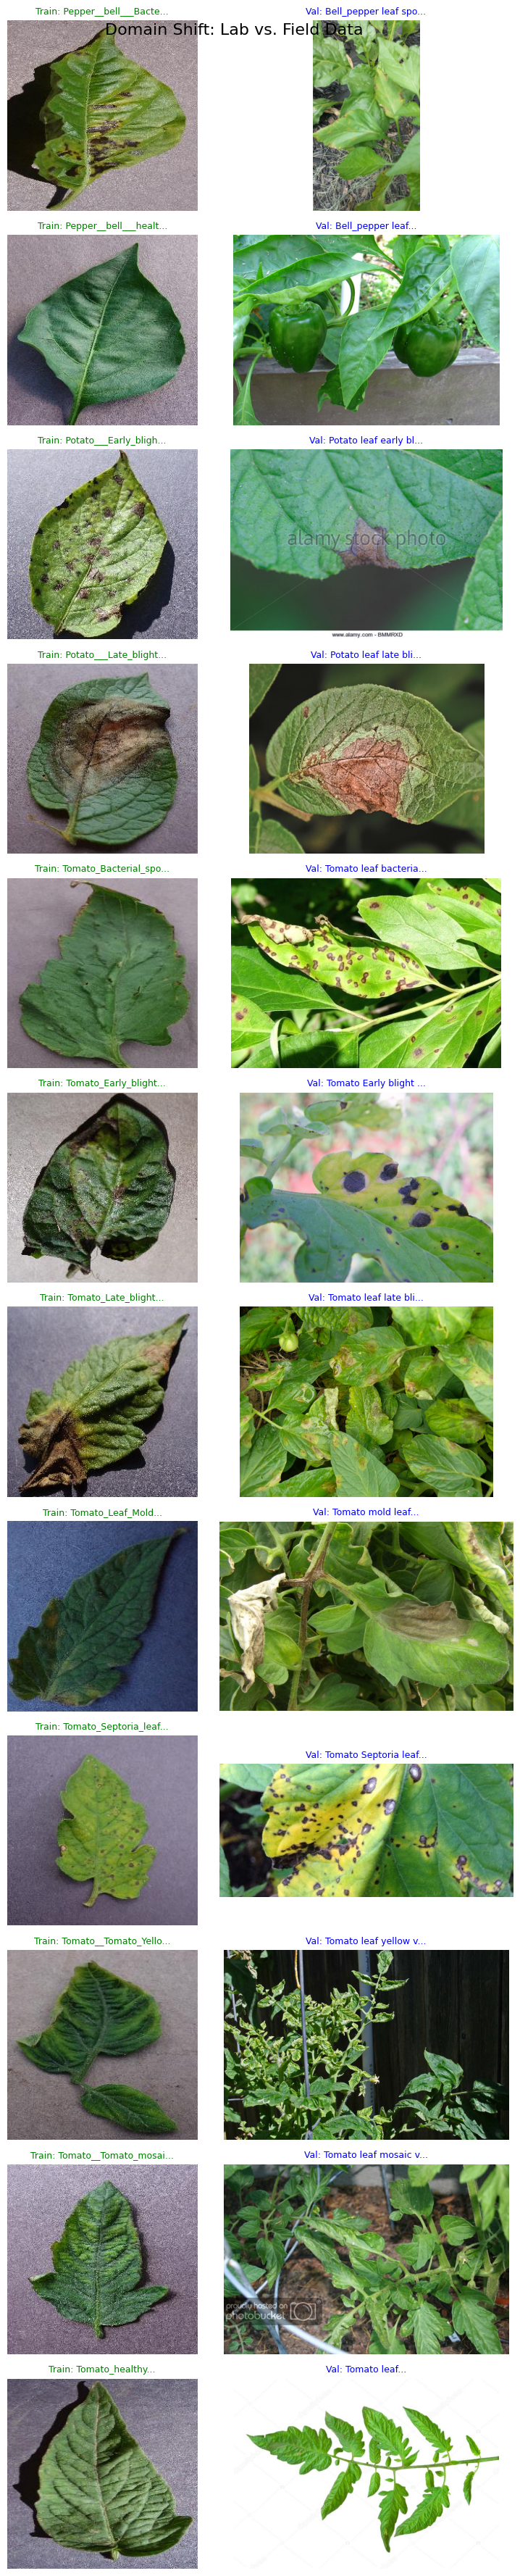

In [7]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

# Use the mapping defined earlier
classes_to_viz = list(CLASS_MAPPING.keys())

# Setup the plot
fig, axes = plt.subplots(len(classes_to_viz), 2, figsize=(8, 3*len(classes_to_viz)))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

def load_random_img(root, class_name):
    class_path = os.path.join(root, class_name)
    if not os.path.exists(class_path): return None
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    if not files: return None
    return Image.open(os.path.join(class_path, random.choice(files)))

print("Generating Domain Shift Visualization...")

for idx, pv_class in enumerate(classes_to_viz):
    img_pv = load_random_img(pv_path, pv_class)
    
    pd_class = CLASS_MAPPING[pv_class]
    img_pd = load_random_img(pd_path, pd_class)
    
    # Plot Left (Train)
    ax_left = axes[idx, 0]
    if img_pv:
        ax_left.imshow(img_pv)
        ax_left.set_title(f"Train: {pv_class[:20]}...", fontsize=9, color='green')
    ax_left.axis('off')

    # Plot Right (Val)
    ax_right = axes[idx, 1]
    if img_pd:
        ax_right.imshow(img_pd)
        ax_right.set_title(f"Val: {pd_class[:20]}...", fontsize=9, color='blue')
    else:
        ax_right.text(0.5, 0.5, "Missing", ha='center')
    ax_right.axis('off')

plt.suptitle("Domain Shift: Lab vs. Field Data", fontsize=16)
plt.tight_layout()
plt.savefig("domain_shift_analysis.png")
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import time
import copy
from tqdm.auto import tqdm  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on Device: {device}")

# Hyperparameters
LEARNING_RATE = 5e-5
EPOCHS = 8
WEIGHT_DECAY = 0.01

num_classes = len(CLASS_MAPPING) 
print(f"Loading ViT-Tiny for {num_classes} classes")
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Wrap loader with tqdm for a progress bar
    loop = tqdm(loader, desc="Training", leave=False) 
    
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Stats
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar description
        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)
        
    return running_loss / len(loader.dataset), 100 * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Wrap validation loader too
    loop = tqdm(loader, desc="Validating", leave=False)
    
    with torch.no_grad():
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            loop.set_postfix(loss=loss.item(), acc=100 * correct / total)
            
    return running_loss / len(loader.dataset), 100 * correct / total


train_loss_history = []
val_acc_history = []
best_acc = 0.0

print(f"\nStarting Training for {EPOCHS} Epochs...")
print("-" * 75)
print(f"{'Epoch':<10} | {'Time':<10} | {'Train Loss':<12} | {'Val Acc':<12} | {'Status'}")
print("-" * 75)

for epoch in range(EPOCHS):
    start_time = time.time()
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_loss_history.append(train_loss)
    val_acc_history.append(val_acc)
    
    saved_tag = ""
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_vit_plant_disease.pth")
        saved_tag = "SAVED"
        
    epoch_time = time.time() - start_time
    
    # Print Clean Log Row
    print(f"{epoch+1:<10} | {epoch_time:.0f}s        | {train_loss:.4f}       | {val_acc:.2f}%      | {saved_tag}")

print("-" * 75)
print(f"Best Real-World Validation Accuracy: {best_acc:.2f}%")

Training on Device: cuda
Loading ViT-Tiny for 12 classes


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


Starting Training for 8 Epochs...
---------------------------------------------------------------------------
Epoch      | Time       | Train Loss   | Val Acc      | Status
---------------------------------------------------------------------------


Training:   0%|          | 0/544 [00:00<?, ?it/s]

Validating:   0%|          | 0/31 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/31 [00:00<?, ?it/s]

7          | 234s        | 0.0190       | 21.67%      | 


Training:   0%|          | 0/544 [00:00<?, ?it/s]

Validating:   0%|          | 0/31 [00:00<?, ?it/s]

8          | 239s        | 0.0145       | 22.89%      | 
---------------------------------------------------------------------------
Best Real-World Validation Accuracy: 25.03%


In [10]:
# Function to calculate accuracy per class
def per_class_accuracy(model, loader, classes):
    model.eval()
    class_correct = list(0. for i in range(len(classes)))
    class_total = list(0. for i in range(len(classes)))
    
    print("analyzing failure modes per class...")
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            # Compare predictions
            c = (predicted == labels).squeeze()
            
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    print("\n--- DIAGNOSTIC REPORT ---")
    print(f"{'Class Name':<40} | {'Accuracy':<10} | {'Samples'}")
    print("-" * 65)
    
    for i in range(len(classes)):
        if class_total[i] > 0:
            acc = 100 * class_correct[i] / class_total[i]
            print(f"{classes[i]:<40} | {acc:.1f}%      | {int(class_total[i])}")
        else:
            print(f"{classes[i]:<40} | N/A        | 0")

per_class_accuracy(model, val_loader, train_dataset.classes)

analyzing failure modes per class...

--- DIAGNOSTIC REPORT ---
Class Name                               | Accuracy   | Samples
-----------------------------------------------------------------
Pepper__bell___Bacterial_spot            | 30.6%      | 62
Pepper__bell___healthy                   | 24.5%      | 53
Potato___Early_blight                    | 11.9%      | 109
Potato___Late_blight                     | 9.3%      | 97
Tomato_Bacterial_spot                    | 1.0%      | 98
Tomato_Early_blight                      | 52.7%      | 74
Tomato_Late_blight                       | 80.2%      | 101
Tomato_Leaf_Mold                         | 0.0%      | 85
Tomato_Septoria_leaf_spot                | 24.1%      | 137
Tomato__Tomato_YellowLeaf__Curl_Virus    | 21.7%      | 69
Tomato__Tomato_mosaic_virus              | 0.0%      | 44
Tomato_healthy                           | 3.7%      | 54
